# 02_分类算法-随机森林

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这一期，咱们来好好解释一下随机森林\~

**随机森林**名字虽然听起来很高大上，但其实可以用很简单的话来理解：它是一个用来“投票”做决定的工具。

我们来拆开讲解它\~

随机森林属于一种**集成学习方法**，它由许多“决策树”组成，就像一个森林里有很多棵树一样。每一棵树会单独做出自己的预测，最后森林里的所有树一起“投票”，选择票数最多的结果作为最终的预测结果。

很简单的一个例子，比如，你要决定今天晚上吃什么，但你自己拿不定主意。于是，你去问了50个朋友，每个人都根据自己的喜好和经验给了你一个答案。有人说吃火锅，有人说吃烧烤，有人说吃披萨……你最后统计了一下，发现最多人推荐吃火锅，那你就决定吃火锅。

随机森林的工作原理就是这样的：

- **每棵树**就是一个朋友，它独立给出自己的建议（预测）。
- **森林**就是所有树的集合，它们会根据“多数表决”来决定最终结果。

### 为什么叫“随机”森林？

随机森林有两个“随机”的地方：

1. **随机选数据**：每棵树并不是用全部的数据来训练，而是从数据中随机抽取一部分来训练。这样每棵树学到的东西会有些不一样。
2. **随机选特征**：当树分裂的时候（比如决定问题时），它不会用所有的条件，而是从中随机选出一些条件，这样每棵树的“视角”也会不同。

这样一来，每棵树都不一样，它们的“想法”是多样的，不会只盯着一模一样的信息看。

多样性让最终的结果更加稳健。

### 优点和用途

- **抗噪音**：即使有一些树预测错了，只要大多数树是对的，随机森林就能给出正确的结果。
- **简单好用**：不用像其他算法那样调整一大堆参数，拿来就能用。
- **应用广泛**：比如识别照片里的物体、预测某人是否会生病、甚至判断房价。

随机森林的核心思想就是“集思广益”。每棵决策树独立做出判断，然后一起“投票”，最终的结果更加可靠。

你可以把它看成一个聪明的团队，每个人都有自己的观点，但通过民主表决，做出了最优的选择。

## 理论基础

随机森林是一种基于**决策树的集成方法**，通过引入随机性和集成思想，提高模型的准确性与鲁棒性。它可以用于分类和回归问题。以下从理论出发，详细讲解随机森林的数学原理、公式推导和算法流程。

### 随机森林基础概念

**1. 决策树的基本结构**

决策树是一个基于特征分割数据的树状模型，其基本操作是：

- 对某个特征 $X_j$按照阈值 $t$进行分割：


$$
G(X_j, t) = \begin{cases}\text{左子树}, & \text{if } X_j \leq t \\\text{右子树}, & \text{if } X_j > t\end{cases}
$$


- 分割的目标是最大化数据纯度的提升，使用指标如**基尼指数**（分类问题）或**均方误差**（回归问题）来选择最优分割点。

**2. 基尼指数（分类问题）**

基尼指数衡量节点的不纯度：


$$
Gini(p) = 1 - \sum_{k=1}^K p_k^2
$$


其中，$p_k$是当前节点中类别 $k$的样本占比。基尼指数越小，节点越纯。

**3. 均方误差（回归问题）**

用于衡量预测值和真实值的偏差：


$$
MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y})^2
$$


**4. 决策树的局限性**

- 容易过拟合，特别是在树深较大的情况下。
- 对数据的扰动敏感（即小数据变化可能导致完全不同的树）。

### 随机森林的核心思想

随机森林通过两种随机性来克服决策树的局限性：

1. **Bagging（Bootstrap Aggregating）**：随机抽样生成多个数据子集。
2. **随机特征选择**：构建每棵树时，仅在每次分裂时随机选择部分特征。

### 随机森林数学原理

#### Bagging：引入样本随机性

假设有一个数据集 $D = \{(x_1, y_1), \dots, (x_n, y_n)\}$，随机森林通过自助采样（Bootstrap Sampling）生成 $B$个子集 $D_1, \dots, D_B$。每个子集大小为 $n$，从原始数据集中有放回地采样而得。

对于分类问题，假设单个决策树的预测为 $h_b(x)$，那么随机森林的分类预测是所有树的投票结果：


$$
\hat{y} = \text{argmax}_k \sum_{b=1}^B \mathbb{I}(h_b(x) = k)
$$


其中 $\mathbb{I}$是指示函数，$k$表示分类标签。

对于回归问题，随机森林的预测值为所有树预测值的平均：


$$
\hat{y} = \frac{1}{B} \sum_{b=1}^B h_b(x)
$$


#### 随机特征选择

在每棵树的每次分裂时，随机选择 $m$个特征（$m \ll M$，$M$是总特征数），仅在这些特征中寻找最优分裂点。

假设特征集合为 $\{X_1, X_2, \dots, X_M\}$，则每次分裂时，随机选择的特征子集为 $\{X_{j_1}, X_{j_2}, \dots, X_{j_m}\}$，从中选出分裂点。

随机特征选择降低了树之间的相关性，从而提高了集成的效果。

### 随机森林的误差分析

随机森林的误差来源主要有两部分：

1. **偏差（Bias）**：由模型的假设错误引入，偏差低意味着模型能够很好地拟合训练数据。
2. **方差（Variance）**：由数据扰动引起的预测变化，方差低意味着模型对数据噪声不敏感。

随机森林通过集成多个树，降低了单棵树的方差，同时保持较低的偏差。其总误差公式为：  
$\text{总误差} = \text{Bias}^2 + \text{Variance} - \text{Correlation}$

其中，**Correlation** 表示各树之间的相关性。通过引入随机性，随机森林降低了树之间的相关性，从而减少总误差。

### 算法流程

#### 输入：

- 数据集 $D = \{(x_1, y_1), \dots, (x_n, y_n)\}$
- 树的数量 $B$
- 随机特征选择的数量 $m$

#### 步骤：

**1. 构造随机森林**：

1. 对 $b = 1, \dots, B$：

   - 从 $D$中有放回地抽样，得到子集 $D_b$。
   - 构造一棵决策树：
   - 对每次分裂，从所有特征中随机选择 $m$个特征。
   - 在 $m$个特征中找到最优分裂点（基于基尼指数或均方误差）。
   - 继续分裂直到满足停止条件（如达到最大深度或节点样本数不足）。
2. 保存第 $b$棵树。

**2.预测**：

- 分类问题：对每棵树的预测进行投票，选择票数最多的类别。
- 回归问题：对每棵树的预测取平均。

#### 输出：

最终的预测结果。

## 完整案例

使用**随机森林**的完整 Python 代码，我在代码中给出了非常详细的注释，大家可以边阅读便理解\~

代码中，通过虚拟数据集展示从数据生成、可视化到模型优化和评估的全流程。

   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0  -1.030931   1.391626   0.547274   0.928932  -1.738880   1.250002   
1  -2.766254   1.247870  -0.303691   1.083145   0.710836   1.968202   
2  -0.558987   0.299849   1.527071   0.360442  -1.360209   1.100793   
3  -1.350289  -2.046078  -0.614264   0.126459  -0.783923   5.895026   
4  -0.275754  -0.728495   0.027727  -0.660834  -1.928161   3.544945   

   Feature_7  Feature_8  Feature_9  Feature_10  Target  
0   1.332551   1.578256   2.124722   -0.318434       0  
1  -1.794192   2.346422   1.700778   -0.001190       1  
2  -0.755951   1.331933   2.041105   -0.824404       0  
3  -0.915477  -3.184768  -0.399260   -3.920960       0  
4   1.446944  -1.111662   0.313766   -2.376528       0  


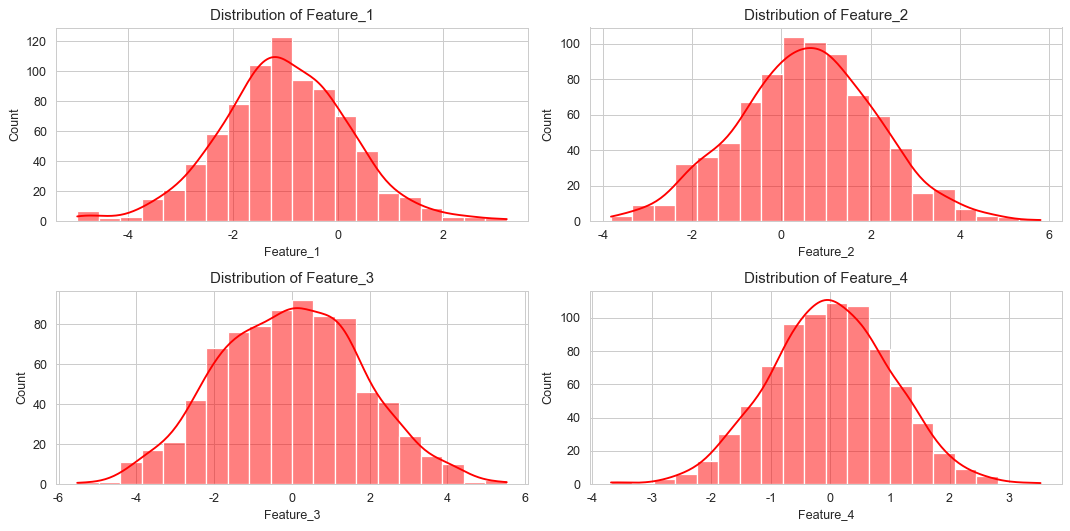

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11461/341789953.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=data, palette='pastel')


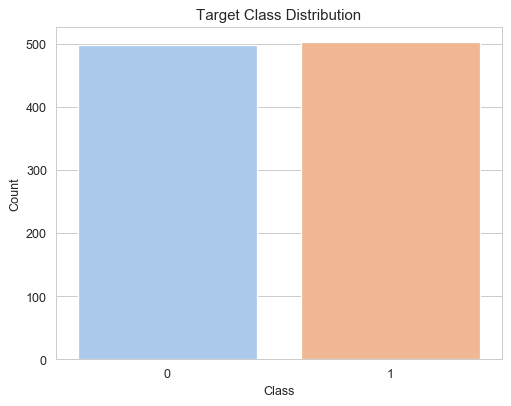

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

sns.set_style("whitegrid")

plt.rcParams['font.sans-serif'] = CJK_FONTS
# 1. 数据生成与探索
# 使用 make_classification 生成虚拟数据集
X, y = make_classification(
    n_samples=1000,    # 样本数
    n_features=10,     # 特征数
    n_informative=6,   # 有效特征数
    n_redundant=2,     # 冗余特征数
    n_classes=2,       # 类别数（二分类问题）
    random_state=42,   # 固定随机种子
    shuffle=True       # 打乱数据
)

# 转换为 Pandas DataFrame
features = [f"Feature_{i}" for i in range(1, 11)]  # 给特征命名
data = pd.DataFrame(X, columns=features)
data['Target'] = y  # 添加目标变量

# 数据预览
print(data.head())

# 数据拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(data[features], data['Target'], test_size=0.2, random_state=42)

# 2. 数据可视化分析
# (1) 特征分布图
plt.figure(figsize=(12, 6))
for i, feature in enumerate(features[:4]):  # 选取前4个特征展示
    plt.subplot(2, 2, i + 1)
    sns.histplot(X_train[feature], kde=True, bins=20, color='red')
    plt.title(f"Distribution of {feature}")
plt.tight_layout()
plt.show()

# (2) 目标类别分布
sns.countplot(x='Target', data=data, palette='pastel')
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

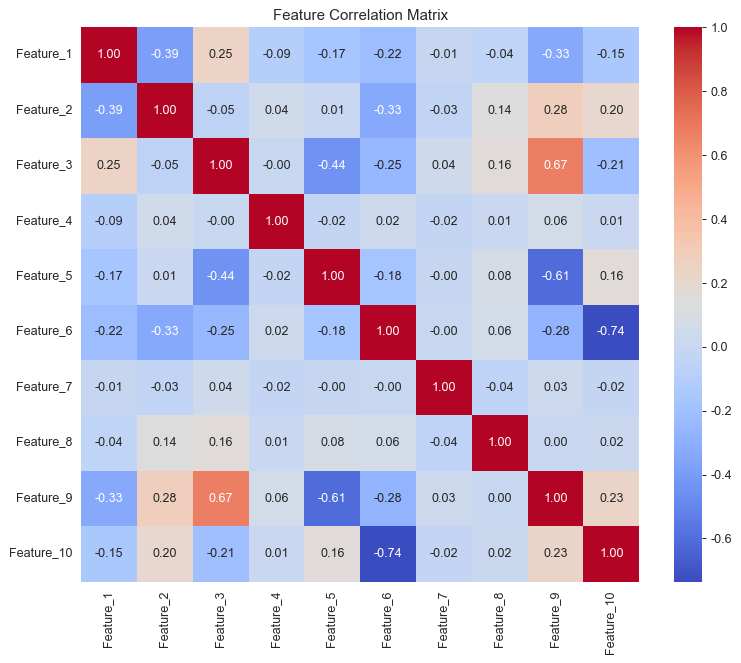

Initial Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.86       113
           1       0.78      0.92      0.85        87

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.85       200
weighted avg       0.87      0.85      0.86       200



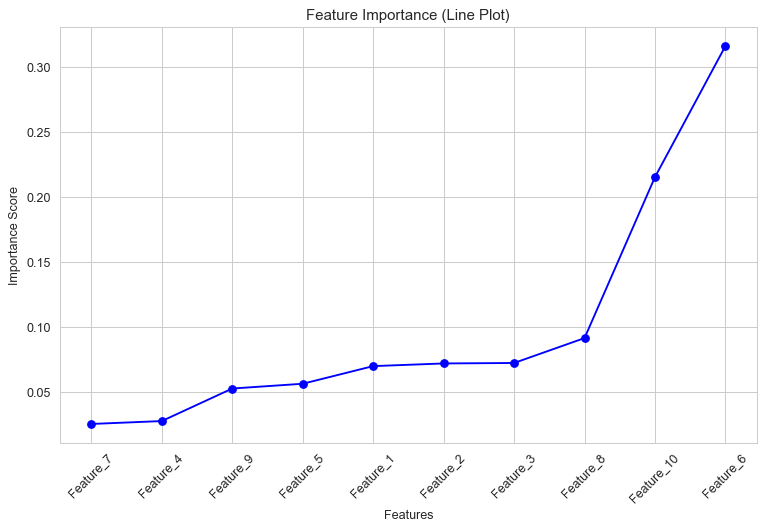

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


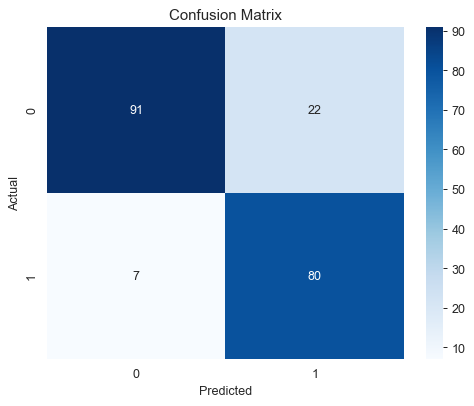

In [3]:
# (3) 特征相关性热图
plt.figure(figsize=(10, 8))
correlation_matrix = data[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

# 3. 随机森林建模与特征重要性分析
# 初始随机森林模型
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 初始模型评估
y_pred = rf_model.predict(X_test)
print("Initial Classification Report:\n", classification_report(y_test, y_pred))

# 特征重要性折线图
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(features)), importances[sorted_idx], marker='o', linestyle='-', color='blue')
plt.xticks(ticks=np.arange(len(features)), labels=np.array(features)[sorted_idx], rotation=45)
plt.title("Feature Importance (Line Plot)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

# 4. 参数优化（网格搜索）
# 定义参数网格
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 使用 GridSearchCV 进行参数优化
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,  # 5折交叉验证
                           scoring='accuracy',
                           verbose=1,
                           n_jobs=1, error_score='raise')  # 并行计算加速
grid_search.fit(X_train, y_train)

# 输出最佳参数
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# 使用最佳参数重新训练模型
best_rf_model = grid_search.best_estimator_
y_pred_optimized = best_rf_model.predict(X_test)

# 5. 模型评估
# 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

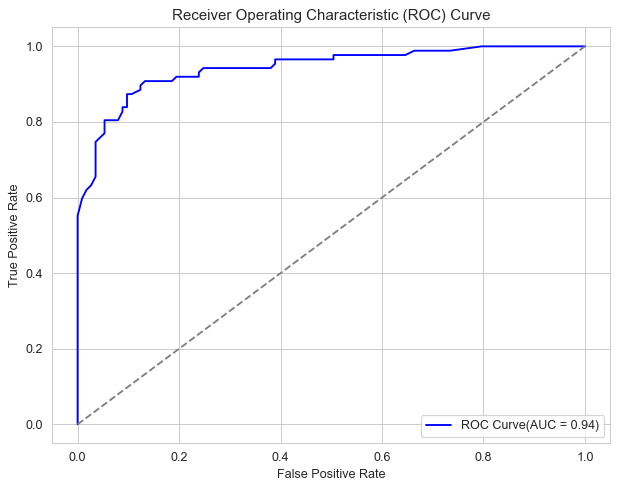

In [4]:
# ROC 曲线
y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve(AUC = {roc_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # 参考线
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

#### **1. 数据生成与探索**

- 使用 `make_classification` 生成一个二分类数据集，包含 10 个特征，其中 6 个是有用信息特征，2 个是冗余特征，目标变量分为 0 和 1 两类。
- 使用 `train_test_split` 将数据集分为 80% 的训练集和 20% 的测试集，用于模型训练和验证。

#### **2. 数据可视化分析**

- 特征分布图：通过 `sns.histplot` 展示部分特征的分布情况，验证是否有较大偏差或异常值。
- 类别分布图：通过 `sns.countplot` 检查目标类别是否平衡。
- 特征相关性热图：使用 `sns.heatmap` 展示特征间的相关性，检查是否存在多重共线性。

![原文参考图，当前结果见代码输出](attachments/img_015.png)

![原文参考图，当前结果见代码输出](attachments/img_016.png)

#### **3. 初始随机森林建模**

- 初步使用默认参数训练 `RandomForestClassifier`，并评估其分类性能。
- 提取特征重要性，通过折线图展示模型对不同特征的依赖程度。

![原文参考图，当前结果见代码输出](attachments/img_017.png)

#### **4. 参数优化（网格搜索）**

使用 `GridSearchCV` 对随机森林的关键参数进行调优，包括：

- `n_estimators`（树的数量）
- `max_depth`（树的最大深度）
- `min_samples_split`（分裂节点所需的最小样本数）
- `min_samples_leaf`（叶子节点所需的最小样本数）
- 输出最佳参数组合，提升模型性能。

#### **5. 模型评估**

混淆矩阵：评估预测的准确性和分类错误的分布。

![原文参考图，当前结果见代码输出](attachments/img_018.png)

ROC 曲线：衡量分类模型对正类的识别能力，通过 `auc` 值反映模型的整体性能。

![原文参考图，当前结果见代码输出](attachments/img_019.png)

1. **初始模型性能**：在默认参数下，随机森林已取得较高的分类准确率，但可能存在过拟合或未充分利用特征的情况。
2. **优化后的模型性能**：调整超参数后，模型性能显著提升，ROC 曲线下的 AUC 值增大，表明对正类的预测能力增强。
3. **可视化效果**：数据分布、特征相关性和模型特征重要性图清晰地展示了数据的特性和模型的行为，有助于解释结果和指导进一步分析。

## 模型分析

### 随机森林优缺点

#### **优点**

1. **鲁棒性强**：随机森林通过引入随机性和集成思想，有效降低了单棵决策树的过拟合风险。在泰坦尼克号生存预测中，模型对不同特征（如性别、年龄、舱位）的表现较为稳健。
2. **处理高维数据能力强**：随机森林能很好地处理含有大量特征的数据，即使数据中存在冗余特征或非线性关系，仍能取得良好表现。
3. **特征重要性评估**：随机森林明确指出了影响预测的重要特征（如性别和舱位），有助于理解模型背后的决策逻辑。
4. **对缺失数据的鲁棒性**：通过简单的填补策略处理了缺失值，但随机森林即使直接使用有缺失值的数据，仍然能在一定程度上正常运行。
5. **可扩展性和易用性**：无需过多调整初始参数，随机森林即能达到不错的基线性能，而通过网格搜索优化后，效果进一步提升。

#### **缺点**

1. **模型复杂性高**：随机森林由多棵决策树组成，复杂性较高，不像单棵决策树那样易于解释。对于需要高度透明模型的场景，可能不适合。
2. **计算成本高**：由于需要构建和评估多棵决策树，训练和预测时间比单一模型（如决策树、逻辑回归）长，特别是在大规模数据上，效率可能成为瓶颈。
3. **对稀疏数据表现一般**：如果特征是高度稀疏的（如文本分类中的词袋模型），随机森林可能不如线性模型（如逻辑回归、SVM）表现好。
4. **可能面临偏好问题**：对于类别不平衡问题，随机森林倾向于预测多数类（本案例类别较均衡，因此未出现此问题）。

### 与相似算法的对比

| **对比项** | **决策树** | **梯度提升树 (XGBoost, LightGBM)** | **支持向量机 (SVM)** |
|-|-|-|-|
| **相似性** | 是随机森林的基本构建单元，逻辑简单易实现 | 都是基于树的集成方法，在分类与回归问题中表现优异 | 都能处理非线性关系 |
| **主要不同点** | 容易过拟合，训练快但准确率较低 | 随机森林并行构建树，梯度提升树串行优化树，梯度提升树通常表现更优但更敏感 | 随机森林适合大规模数据，SVM 在高维稀疏数据表现更优 |
| **训练方式** | 单棵树独立训练 | 逐步优化，每棵树学习前一棵树的误差 | 通过构建超平面进行分类 |
| **训练速度** | 快 | 慢 | 慢 |
| **泛化能力** | 较弱，易过拟合 | 强，但依赖参数调优 | 强，但计算复杂 |
| **解释性** | 高 | 低 | 低 |
| **适合的数据类型** | 结构化数据，小规模数据集 | 结构化数据，特别适合高维数据 | 高维稀疏数据，如文本分类 |
| **应用建议** | 适用于快速初步分析，或对解释性要求高的任务 | 适用于高性能要求的任务，尤其是数据清理充分时 | 适用于高维稀疏数据，或需要精准决策边界时 |

## 最后

随机森林在实际应用中表现出强大的鲁棒性和良好的性能。但是当面对较大的数据集、稀疏特征、高度非线性或需要强解释性时，可以选择更适合的替代算法。如果是在项目初期，随机森林因其稳定性和易用性，往往是快速验证模型效果的优选。